# 05. Train LaBraM and compare runs

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "configs").exists() else Path.cwd().parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

DATA_ROOT = ROOT / "data"
MANIFESTS = DATA_ROOT / "manifests"
RUNS = ROOT / "runs"

EPOCH_INDEX_RAW = MANIFESTS / "epoch_index_yoto_tones.csv"
EPOCH_INDEX_ZUNA = MANIFESTS / "epoch_index_yoto_tones_zuna.csv"

EPOCHS = 5
BATCH_SIZE = 16
LR = 1e-4
DEVICE = "cpu"
CHECKPOINT = ""

Saved Labram metrics to /Users/alexandra.feldman/thesis/identify/runs/labram_metrics_raw.json
Pipeline	Accuracy	N_train	N_test
raw	0.3333	50	48
Saved /Users/alexandra.feldman/thesis/identify/runs/labram_comparison.png


{'accuracy': 0.3333333333333333,
 'n_train': 50,
 'n_test': 48,
 'label_classes': [np.str_('tone_C'), np.str_('tone_D'), np.str_('tone_E')],
 'model': 'labram_base_patch200_200',
 'checkpoint': None,
 'input_shape': [1, 6, 200],
 'note': 'Uses official LaBraM architecture. For best quality, pass a pretrained checkpoint and dataset-specific channel mapping.'}

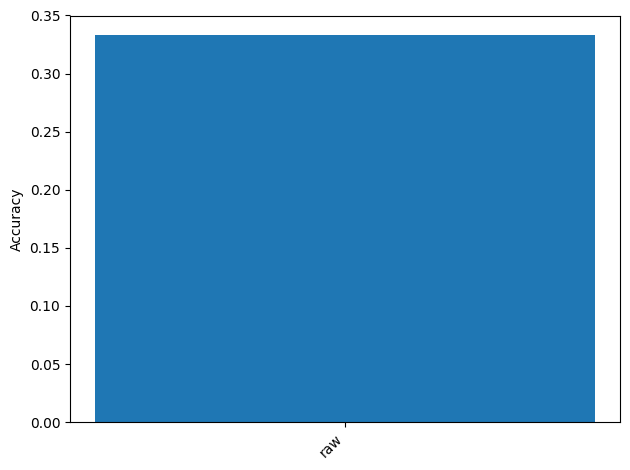

In [5]:
from scripts.compare_labram_runs import compare_labram_runs
from scripts.train_labram import train_labram

metrics_raw = train_labram(
    epoch_index_path=EPOCH_INDEX_RAW,
    out_metrics_path=RUNS / "labram_metrics_raw.json",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    device=DEVICE,
    checkpoint=CHECKPOINT,
)
"""
metrics_raw_zuna = train_labram(
    epoch_index_path=EPOCH_INDEX_ZUNA,
    out_metrics_path=RUNS / "labram_metrics_raw_zuna.json",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    device=DEVICE,
    checkpoint=CHECKPOINT,
)
"""


compare_labram_runs(
    runs_dir=RUNS,
    names=["raw", "raw_zuna"],
    #files=["labram_metrics_raw.json", "labram_metrics_raw_zuna.json"],
    files=["labram_metrics_raw.json"],
    plot=True,
)

#metrics_raw, metrics_raw_zuna
metrics_raw